# Quartz Segmentation model test

In [1]:
import torch
import torch.nn as nn
from torchvision.models.segmentation import fcn_resnet50
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
import io
from IPython.display import Image as IPyImage, display

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.9.1+cu128
CUDA available: True


# Load data

In [2]:
tiff_path = "../data/EFR/Greyscale/EFRGP01_00.tif"

with tifffile.TiffFile(tiff_path) as tif:
    shape = tif.series[0].shape
    print(f"Image dimensions: {shape}")
    print(f"Data type: {tif.series[0].dtype}")
        
    if len(shape) == 3:
        depth, height, width = shape
    elif len(shape) == 2:
        height, width = shape
        depth = 1
    else:
        print("Unexpected image dimensions!")
            
    print(f"Depth (Z): {depth}, Height (Y): {height}, Width (X): {width}")

Image dimensions: (1600, 1400, 1400)
Data type: uint16
Depth (Z): 1600, Height (Y): 1400, Width (X): 1400


## Region subsample

In [3]:
def read_voxel_region(tiff_path, region_size=100, random_offset_range=50):
    with tifffile.TiffFile(tiff_path) as tif:
        shape = tif.series[0].shape
        
        if len(shape) == 3:
            depth, height, width = shape
        elif len(shape) == 2:
            height, width = shape
            depth = 1
        else:
            raise ValueError("Unexpected image dimensions!")
        
        center_z = depth // 2
        center_y = height // 2
        center_x = width // 2
        
        offset_z = random.randint(-random_offset_range, random_offset_range)
        offset_y = random.randint(-random_offset_range, random_offset_range)
        offset_x = random.randint(-random_offset_range, random_offset_range)
        
        start_z = max(0, min(center_z + offset_z - region_size//2, depth - region_size))
        start_y = max(0, min(center_y + offset_y - region_size//2, height - region_size))
        start_x = max(0, min(center_x + offset_x - region_size//2, width - region_size))
        
        end_z = start_z + region_size
        end_y = start_y + region_size
        end_x = start_x + region_size
        
        print(f"Reading region: Z[{start_z}:{end_z}], Y[{start_y}:{end_y}], X[{start_x}:{end_x}]")
        
        region = tif.asarray()[start_z:end_z, start_y:end_y, start_x:end_x]

        
        return region, (start_z, start_y, start_x)

print("Extracting 100x100x100 voxel region...")
voxel_region, start_coords = read_voxel_region(tiff_path, region_size=300, random_offset_range=50)

print(f"Region shape: {voxel_region.shape}")
print(f"Data type: {voxel_region.dtype}")
print(f"Value range: {voxel_region.min()} to {voxel_region.max()}")
print(f"Start coordinates: Z={start_coords[0]}, Y={start_coords[1]}, X={start_coords[2]}")

voxel = voxel_region.astype(np.float32)
print(f"PyTorch tensor shape: {voxel.shape}")
print(f"PyTorch tensor device: {voxel.device}")

Extracting 100x100x100 voxel region...
Reading region: Z[603:903], Y[600:900], X[550:850]
Region shape: (300, 300, 300)
Data type: uint16
Value range: 9814 to 65535
Start coordinates: Z=603, Y=600, X=550
PyTorch tensor shape: (300, 300, 300)
PyTorch tensor device: cpu


## Preprocessing

In [4]:
from scipy.ndimage import binary_erosion
from scipy.ndimage import binary_dilation

def normalize_image(imgs):    
    # on garde que les valeurs positives pour la normalisation
    positive_vals = imgs[imgs > 0]
    mu = np.mean(positive_vals)
    sigma = np.std(positive_vals)
    
    # on mets la normalisation 
    norm_imgs = (imgs - mu) / (5 * sigma)
    
    # Remettre à zéro les valeurs initialement nulles
    norm_imgs[imgs == 0] = 0
    return norm_imgs

def dilate_3d(
    volume: np.ndarray,
    iterations: int = 1,
    structure: np.ndarray | None = None
) -> np.ndarray:
    if volume.ndim != 3:
        raise ValueError("Input must be a 3D array")

    volume = volume.astype(bool)

    if structure is None:
        structure = np.ones((3, 3, 3), dtype=bool)

    dilated = binary_dilation(
        volume,
        structure=structure,
        iterations=iterations
    )

    return dilated.astype(np.uint8)

def erode_3d(
    volume: np.ndarray,
    iterations: int = 1,
    structure: np.ndarray | None = None
) -> np.ndarray:
    if volume.ndim != 3:
        raise ValueError("Input must be a 3D array")

    volume = volume.astype(bool)

    if structure is None:
        structure = np.ones((3, 3, 3), dtype=bool)

    eroded = binary_erosion(
        volume,
        structure=structure,
        iterations=iterations
    )
    return eroded.astype(np.uint8)

# Normalize image
voxel_normalized = normalize_image(voxel)

# Binarize image
voxel_binary = np.where(voxel_normalized[:] < 0, 1, 0)
voxel_tensor_unerosed = torch.from_numpy(voxel_binary.astype(np.float32)).to("cuda")

# Erosion
for _ in range(4) :
    voxel_binary = dilate_3d(voxel_binary, iterations=4)
    voxel_binary = erode_3d(voxel_binary, iterations=4)

# To tensor
voxel_tensor = torch.from_numpy(voxel_binary.astype(np.float32)).to("cuda")

# Model Inference

Prediction shape: torch.Size([1, 21, 512, 512])
Seg map unique classes: tensor([0], device='cuda:0')


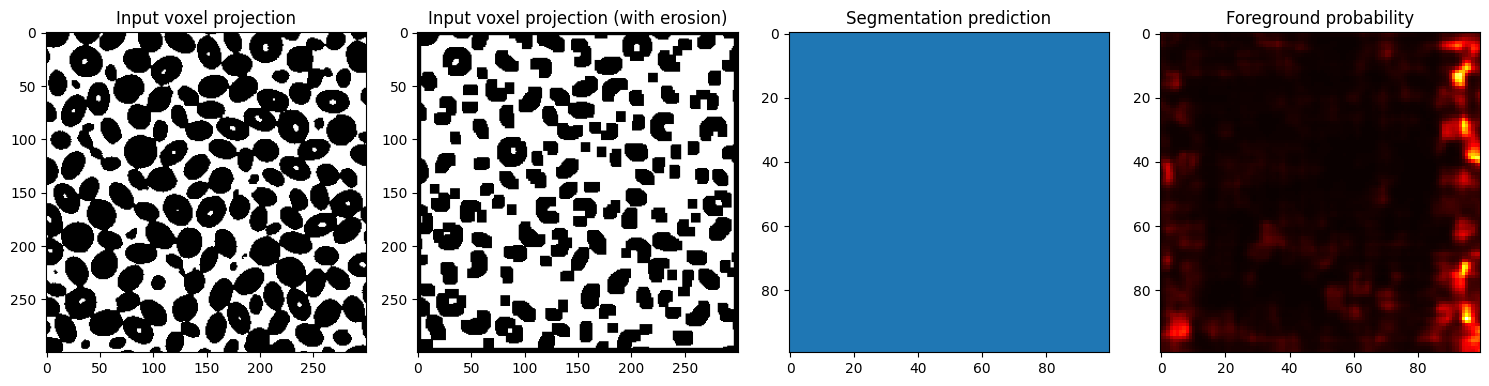

In [6]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.transforms.functional import resize, normalize

INDEX = 40

# Load pre-trained FCN-ResNet50 with num_classes adjusted for the paper
# (e.g., 3 classes for quartz particle sizes: small/medium/large + background)
model = fcn_resnet50(pretrained=True, num_classes=21)  # Adjust num_classes as needed[file:34]
model.eval().cuda()  # Set to eval mode on GPU

# 1. Preprocess the 3D voxel tensor for 2D FCN-ResNet50
# - Project to 2D: e.g., max-pool along Z (or mean/sum for intensity)
voxel_2d = voxel_tensor[INDEX]
#voxel_2d = voxel_tensor_unerosed[INDEX]

# - Resize to model input size (e.g., 512x512), normalize to 3 channels (grayscale replicated)
input_img = resize(voxel_2d.unsqueeze(0).unsqueeze(0), [512, 512])  # [1, 1, 512, 512]
input_img = input_img.repeat(1, 3, 1, 1)  # Replicate to RGB: [1, 3, 512, 512]
input_img = normalize(input_img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet stats

# 2. Forward pass
with torch.no_grad():
    pred = model(input_img)['out']  # [1, num_classes, 512, 512]
    pred_prob = F.softmax(pred, dim=1)[:, 1]  # Example: foreground probability [1, 512, 512]
    pred_seg = torch.argmax(pred, dim=1)  # Segmentation map [1, 512, 512]

print(f"Prediction shape: {pred.shape}")
print(f"Seg map unique classes: {torch.unique(pred_seg)}")

# 3. Resize back to original size and visualize
pred_seg_resized = resize(pred_seg.float(), [100, 100])  # Back to voxel slice size
pred_prob_resized = resize(pred_prob, [100, 100])

# Display using matplotlib (colormap for segmentation)
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(voxel_tensor_unerosed[INDEX].cpu().numpy(), cmap='gray')
axs[0].set_title('Input voxel projection')
axs[1].imshow(voxel_2d.cpu().numpy(), cmap='gray')
axs[1].set_title('Input voxel projection (with erosion)')
axs[2].imshow(pred_seg_resized[0].cpu().numpy(), cmap='tab20')
axs[2].set_title('Segmentation prediction')
axs[3].imshow(pred_prob_resized[0].cpu().numpy(), cmap='hot')
axs[3].set_title('Foreground probability')
plt.tight_layout()
plt.show()  # Or plt.savefig('prediction.png')
